Проект: вариант 1.

Представьте, что вы работаете в компании, которая разрабатывает мобильные игры. К вам пришел менеджер с рядом задач по исследованию нескольких аспектов мобильного приложения:

1. В первую очередь, его интересует показатель retention. Напишите функцию для его подсчета.
2. Помимо этого, в компании провели A/B тестирование наборов акционных предложений. На основе имеющихся данных определите, какой набор можно считать лучшим и на основе каких метрик стоит принять правильное решение.
3. Предложите метрики для оценки результатов последнего прошедшего тематического события в игре.

Задание 1.
Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока).

У нас имеется два датасета с данными о времени регистрации пользователей и временем захода пользователей в игру.
Для начала прочитаем данные и посмотрим на типы данных. 

In [223]:
import pandas as pd
import numpy as np
import pingouin as pg
import scipy.stats as st
from scipy.stats import chi2_contingency

In [224]:
# в качестве разделителя указываем ;, так как именно он разделяет значения в файле

reg_time = pd.read_csv('problem1-reg_data.csv', sep=';')
reg_time.head()

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


In [225]:
# проверяем типы данных

reg_time.dtypes

reg_ts    int64
uid       int64
dtype: object

In [226]:
# колонку reg_ts необходимо привести к формату даты (время представлено в секундах, прошедших 
# с 1 января 1970 года)

reg_time['reg_ts'] = pd.to_datetime(reg_time['reg_ts'], unit='s')


In [227]:
# оставим только даты без точного времени

reg_time['reg_ts'] = reg_time['reg_ts'].dt.date

In [228]:
reg_time.head()

,reg_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,2000-01-13,3
3,2000-05-28,4
4,2000-09-16,5


Делаем все аналогично для данных о времени захода пользователей в игру:

In [229]:
# в качестве разделителя указываем ;, так как именно он разделяет значения в файле

auth_time = pd.read_csv('problem1-auth_data.csv', sep=';')
auth_time.head()

,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


In [230]:
# проверяем типы данных

auth_time.dtypes

auth_ts    int64
uid        int64
dtype: object

In [231]:
# колонку auth_ts необходимо привести к формату даты (время представлено в секундах, прошедших 
# с 1 января 1970 года)

auth_time['auth_ts'] = pd.to_datetime(auth_time['auth_ts'], unit='s')

In [233]:
auth_time.head()

,auth_ts,uid
0,1998-11-18 09:43:43,1
1,1999-07-22 22:38:09,2
2,1999-07-25 16:46:46,2
3,1999-07-31 03:50:15,2
4,1999-08-05 17:49:39,2


In [234]:
# оставим только даты без точного времени

auth_time['auth_ts'] = auth_time['auth_ts'].dt.date

In [235]:
auth_time.head()

,auth_ts,uid
0,1998-11-18,1
1,1999-07-22,2
2,1999-07-25,2
3,1999-07-31,2
4,1999-08-05,2


Теперь объединим две таблицы и переименуем столбцы для удобства.

In [236]:
df = pd.merge(reg_time, auth_time, on='uid', how='inner')

In [239]:
df = df.rename(columns={'reg_ts': 'reg_date', 'uid': 'user_id', 'auth_ts': 'auth_date'})
df


,reg_date,user_id,auth_date
0,1998-11-18,1,1998-11-18
1,1999-07-22,2,1999-07-22
2,1999-07-22,2,1999-07-25
3,1999-07-22,2,1999-07-31
4,1999-07-22,2,1999-08-05
...,...,...,...
9601008,2020-09-23,1110618,2020-09-23
9601009,2020-09-23,1110619,2020-09-23
9601010,2020-09-23,1110620,2020-09-23
9601011,2020-09-23,1110621,2020-09-23


1. В первую очередь, посчитаем показатель retention. Напишем функцию для подсчета возвращаемости (или удержание) игроков по дням от даты регистрации игроков.

In [240]:
# так как датасет большой, будем тестировать функцию на части данных (сэмпле).
# Можно выбрать либо первые n-строк, либо рандомным оразом выбирать данные из датасета

# sample = df.sample(n=1000)

sample = df.head(10000)
sample

,reg_date,user_id,auth_date
0,1998-11-18,1,1998-11-18
1,1999-07-22,2,1999-07-22
2,1999-07-22,2,1999-07-25
3,1999-07-22,2,1999-07-31
4,1999-07-22,2,1999-08-05
...,...,...,...
9995,2006-07-07,212,2017-03-27
9996,2006-07-07,212,2017-03-30
9997,2006-07-07,212,2017-04-04
9998,2006-07-07,212,2017-04-05


In [241]:
# для удобства дальнейших вычислений изменим тип данных колонки user_id на строковый
# отсортируем даты регистрации по возрастанию (если используем сэмплирование)

sample['user_id'] = sample['user_id'].apply(str)
sample = sample.sort_values(by='reg_date')
sample

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


,reg_date,user_id,auth_date
0,1998-11-18,1,1998-11-18
1294,1999-07-22,2,2013-10-06
1293,1999-07-22,2,2013-10-02
1292,1999-07-22,2,2013-09-26
1291,1999-07-22,2,2013-09-21
...,...,...,...
9351,2006-07-07,212,2010-01-22
9352,2006-07-07,212,2010-01-27
9353,2006-07-07,212,2010-02-02
9355,2006-07-07,212,2010-02-14


In [245]:
def retention(sample):
    
    """
    Функция рассчитывает возвращаемость игроков для каждого дня регистрации
    
    Параметры функции: датафрейм sample с колонками 'reg_date','auth_date' и 'user_id'
    
    Функция возвращает: новый датафрейм results с колонками: 'reg_date', 'total_users', 'new_users' и 'retention_rate'. 
    
    """
   
    # Уникальные даты регистрации
    unique_reg_dates = sample['reg_date'].unique()

    # Создаем пустой датафрейм для сохранения результатов
    results = pd.DataFrame(columns=['reg_date', 'total_users', 'active_users', 'new_users', 'retention_rate'])
    
    
    for reg_date in unique_reg_dates:

        # Создаем список уникальных пользователей, зареистрировавшихся в определенный день
        reg_users = sample.query("reg_date <= @reg_date")['user_id'].unique()

        # Общее количество уникальных пользователей, зарегистрировавшихся в этот день
        # (или количество клиентов в начале периода)
        total_users = len(reg_users)

        # Количество активных пользователей, которые продолжают заходить в игру в определенный день
        # (или количество клиентов на конец периода)
        active_users = sample.query("auth_date >= @reg_date and user_id in @reg_users")['user_id'].nunique()
        
        # Количество новых пользователей (количество новых клиентов на конец периода)
        new_users = sample.query("reg_date == @reg_date")['user_id'].nunique()
        
        # Возвращаемость
        retention_rate = 100 *(active_users - new_users) / total_users

        # Добавляем результаты в результирующий датафрейм
        results = results.append({
                'reg_date': reg_date,
                'total_users': total_users,
                'active_users': active_users,
                'new_users': new_users,
                'retention_rate': retention_rate}, ignore_index=True)

    return results


In [246]:
df_retention = retention(sample)
df_retention['retention_rate'] = df_retention['retention_rate'].round(2)

In [251]:
df_retention.head(20)

,reg_date,total_users,active_users,new_users,retention_rate
0,1998-11-18,1,1,1,0.00
1,1999-07-22,2,1,1,0.00
2,2000-01-13,3,2,1,33.33
3,2000-05-28,4,2,1,25.00
4,2000-09-16,5,2,1,20.00
5,2000-12-19,6,2,1,16.67
6,2001-03-10,7,2,1,14.29
7,2001-05-21,8,2,1,12.50
8,2001-07-24,9,2,1,11.11
9,2001-09-20,10,2,1,10.00


Была подчситана метрика, которая показывает, какой процент пользователей продолжает использовать продукт или возвращается спустя определённое время после первого взаимодействия. В контексте игр и приложений это ключевой показатель, демонстрирующий уровень вовлечённости и удовлетворённости пользователей.

In [ ]:
# ______________________________________________________________________________________#


Задание 2.
Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

Для начала прочитаем датасет и посмотрим на типы данных

In [252]:
# в качестве разделителя указываем ;, так как именно он разделяет значения в файле

df_ab_test = pd.read_csv('project.csv', sep=';')
df_ab_test
# a - control, b - test

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [253]:
df_ab_test.dtypes

user_id       int64
revenue       int64
testgroup    object
dtype: object

По условию нам дано, что в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667. По этим данным определим, какая группа обозначается, как a, а какая b.

In [254]:
df_ab_test.query('testgroup == "a" and revenue > 0').user_id.nunique()

1928

In [255]:
df_ab_test.query('testgroup == "b" and revenue > 0').user_id.nunique()

1805

Таким оразом выяснили, что а - это контрольная группа, b - это тестовая группа.

В качестве первой метрики для анализа возьмем ARPU - средний доход с привлеченного пользователя. Рассчитаем этот показатель для двух групп:

In [256]:
arpu_control = df_ab_test.query('testgroup == "a"').revenue.sum()/ df_ab_test.query('testgroup == "a"').user_id.nunique()
arpu_control.round(1)   

25.4

In [257]:
arpu_test = df_ab_test.query('testgroup == "b"').revenue.sum()/ df_ab_test.query('testgroup == "b"').user_id.nunique()
arpu_test.round(1)                         


26.8

Обоснование выбора статистического критерия.

Для статистического сравнения метрики ARPU в двух группах будем использовать выборки доходов (средний доход). Для этого подходит t-тест (хотим сравнить средние значения двух независимых выборок). 
Тип данных: ARPU — это количественная метрика, которая может быть нормально распределена, что делает t-тест подходящим выбором. Более того две группы должны быть независимыми друг от друга, то есть выборка пользователей из одной группы не должна влиять на выборку пользователей из другой группы. Дисперсии двух групп должны быть равны. Это можно проверить с помощью теста Левена.

Нулевая гипотеза Но: ARPU в двух группах a и b не отличаются.
Альтернативная гипотеза H1 - ARPU в двух группах a и b статзначимо отличаются.
Уровень значимсоти выберем 5 %.

Построим диаграммы распределения среднего дохода для контрольной и тестовой групп и проверим эти рапределения на нормальность.

In [258]:
df_ab_test.query('testgroup == "a"').revenue.describe()

count    202103.000000
mean         25.413720
std         920.768137
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       37433.000000
Name: revenue, dtype: float64

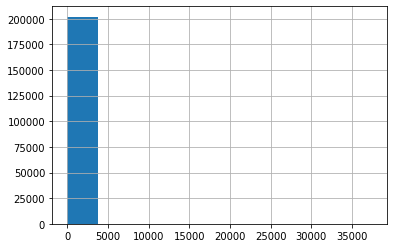

In [259]:
df_ab_test.query('testgroup == "a"').revenue.hist()

In [260]:
# тест на нормальность по Шапиро

pg.normality(df_ab_test.query('testgroup == "a"').revenue, method='shapiro')

/opt/tljh/user/lib/python3.7/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


,W,pval,normal
revenue,0.008877,0.0,False


In [261]:
# тест на нормальность по альтернативному тесту

pg.normality(df_ab_test.query('testgroup == "a"').revenue, method='normaltest')

,W,pval,normal
revenue,585152.731273,0.0,False


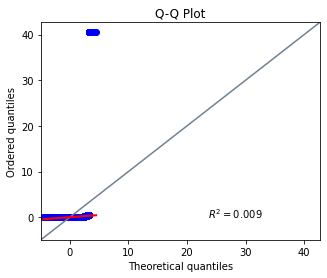

In [262]:
# вариант с qq-плотом

pg.qqplot(df_ab_test.query('testgroup == "a"').revenue)

In [263]:
df_ab_test.query('testgroup == "b"').revenue.describe()

count    202667.000000
mean         26.751287
std         287.324162
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        4000.000000
Name: revenue, dtype: float64

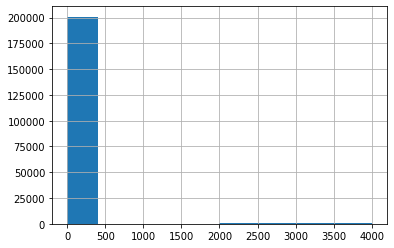

In [264]:
df_ab_test.query('testgroup == "b"').revenue.hist()

In [265]:
# тест на нормальность по Шапиро

pg.normality(df_ab_test.query('testgroup == "b"').revenue, method='shapiro')

/opt/tljh/user/lib/python3.7/site-packages/scipy/stats/morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


,W,pval,normal
revenue,0.065882,0.0,False


In [266]:
# тест на нормальность по альтернативному тесту

pg.normality(df_ab_test.query('testgroup == "b"').revenue, method='normaltest')

,W,pval,normal
revenue,326622.395409,0.0,False


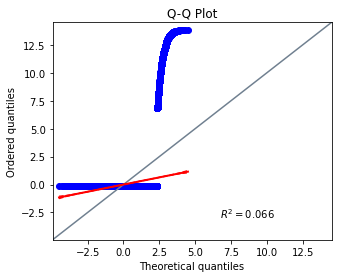

In [267]:
# вариант с qq-плотом

pg.qqplot(df_ab_test.query('testgroup == "b"').revenue)

Для анализа гомогенности дисперсий воспользуемся тестом Левена:

In [268]:
levene_test = st.levene(df_ab_test.query('testgroup == "a"').revenue, df_ab_test.query('testgroup == "b"').revenue)
levene_test

LeveneResult(statistic=0.3896289474701388, pvalue=0.5324948591043842)

Из анализа выше видно, что рапределения в обеих группах нельзя назвать нормальными, однако гомогенность дисперсий сохраняется (p-value > 0.05). На практике t-тест может быть использован для сравнения средних и при ненормальном распределении, особенно на больших выборках и если в данных нет заметных выбросов, поэтому воспользуемся т-тестом.

In [270]:
# scipy

st.ttest_ind(a=df_ab_test.query('testgroup == "a"').revenue, 
             b=df_ab_test.query('testgroup == "b"').revenue, equal_var=True)

Ttest_indResult(statistic=-0.6242026493616787, pvalue=0.532494858971837)

In [271]:
# pingouin

pg.ttest(x=df_ab_test.query('testgroup == "a"').revenue, 
         y=df_ab_test.query('testgroup == "b"').revenue)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.623488,240991.130782,two-sided,0.532965,"[-5.54, 2.87]",0.001962,0.004,0.095694


Во всех случаях значение p-value оказалось больше 0.05, поэтому у нас нет основания отклонить нулевую гипотезу и слеовательно мы делаем вывод, что ARPU в двух группах значимо не различаются.

В качестве второй метрики для анализа возьмем ARPPU - средний доход с платящего пользователя. Рассчитаем этот показатель для двух групп:

In [272]:
arppu_control = df_ab_test.query('testgroup == "a" and revenue > 0').revenue.sum()/ df_ab_test.query('testgroup == "a" and revenue > 0').user_id.nunique()
arppu_control.round(1)    

2664.0

In [273]:
arppu_test = df_ab_test.query('testgroup == "b" and revenue > 0').revenue.sum()/ df_ab_test.query('testgroup == "b" and revenue > 0').user_id.nunique()
arppu_test.round(1) 

3003.7

Обоснование выбора статистического критерия.

Для статистического сравнения метрики ARPPU в двух группах будем использовать выборки доходов платящих пользователей (средний доход на платящего пользователя). Для этого подходит t-тест (хотим сравнить средние значения двух независимых выборок). Тип данных: ARPPU — это количественная метрика, которая может быть нормально распределена, что делает t-тест подходящим выбором. Более того две группы должны быть независимыми друг от друга, то есть выборка пользователей из одной группы не должна влиять на выборку пользователей из другой группы. Дисперсии двух групп должны быть равны. Это можно проверить с помощью теста Левена.


Нулевая гипотеза Но: ARPPU в двух группах a и b не отличаются.
Альтернативная гипотеза H1 - ARPPU в двух группах a и b статзначимо отличаются. Уровень значимсоти выберем 5 %.

Построим диаграммы распределения среднего дохода для контрольной и тестовой групп и проверим эти рапределения на нормальность и гомогенность дисперсий.


In [274]:
df_ab_test.query('testgroup == "a" and revenue > 0').revenue.describe()

count     1928.000000
mean      2663.998444
std       9049.039763
min        200.000000
25%        257.000000
50%        311.000000
75%        361.000000
max      37433.000000
Name: revenue, dtype: float64

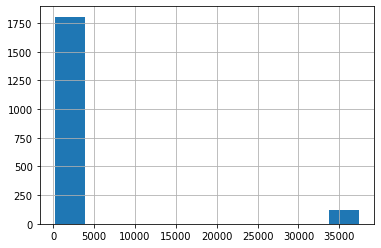

In [275]:
df_ab_test.query('testgroup == "a" and revenue > 0').revenue.hist()

In [276]:
# тест на нормальность по Шапиро

pg.normality(df_ab_test.query('testgroup == "a" and revenue > 0').revenue, method='shapiro')

,W,pval,normal
revenue,0.266792,0.0,False


In [277]:
# тест на нормальность по альтернативному тесту

pg.normality(df_ab_test.query('testgroup == "a" and revenue > 0').revenue, method='normaltest')

,W,pval,normal
revenue,1394.945784,1.234161e-303,False


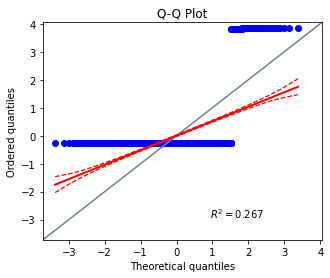

In [278]:
# вариант с qq-плотом

pg.qqplot(df_ab_test.query('testgroup == "a" and revenue > 0').revenue)

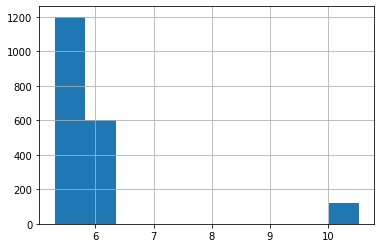

In [279]:
# так как в этой выборке нет нулевых значений, попробуем прологарифмировать данные

np.log(df_ab_test.query('testgroup == "a" and revenue > 0').revenue).hist()

In [280]:
# тест на нормальность по Шапиро

pg.normality(np.log(df_ab_test.query('testgroup == "a" and revenue > 0').revenue), method='shapiro')

,W,pval,normal
revenue,0.409079,0.0,False


In [281]:
# тест на нормальность по альтернативному тесту

pg.normality(np.log(df_ab_test.query('testgroup == "a" and revenue > 0').revenue), method='normaltest')

,W,pval,normal
revenue,1340.721406,7.345912e-292,False


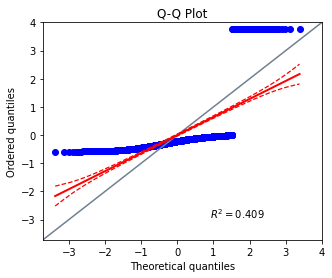

In [282]:
# вариант с qq-плотом

pg.qqplot(np.log(df_ab_test.query('testgroup == "a" and revenue > 0').revenue))

Сделаем аналогичные вычисления для группы b.

In [283]:
df_ab_test.query('testgroup == "b" and revenue > 0').revenue.describe()

count    1805.000000
mean     3003.658172
std       572.619709
min      2000.000000
25%      2513.000000
50%      3022.000000
75%      3478.000000
max      4000.000000
Name: revenue, dtype: float64

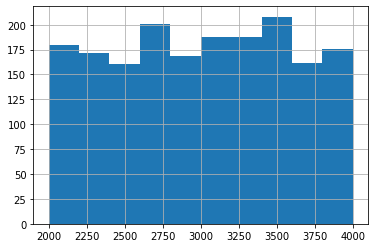

In [284]:
df_ab_test.query('testgroup == "b" and revenue > 0').revenue.hist()

In [285]:
# тест на нормальность по Шапиро

pg.normality(df_ab_test.query('testgroup == "b" and revenue > 0').revenue, method='shapiro')

,W,pval,normal
revenue,0.958312,2.491346e-22,False


In [286]:
# тест на нормальность по альтернативному тесту

pg.normality(df_ab_test.query('testgroup == "b" and revenue > 0').revenue, method='normaltest')

,W,pval,normal
revenue,1068.860008,7.943249e-233,False


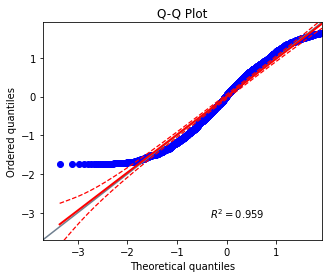

In [287]:
# вариант с qq-плотом

pg.qqplot(df_ab_test.query('testgroup == "b" and revenue > 0').revenue)

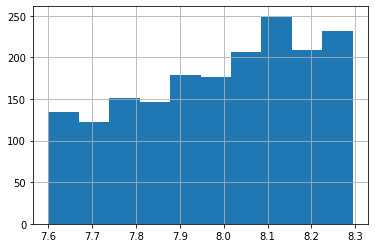

In [288]:
# так как в этой выборке нет нулевых значений, попробуем прологарифмировать данные

np.log(df_ab_test.query('testgroup == "b" and revenue > 0').revenue).hist()

In [289]:
# тест на нормальность по Шапиро

pg.normality(np.log(df_ab_test.query('testgroup == "b" and revenue > 0').revenue), method='shapiro')

,W,pval,normal
revenue,0.951944,6.965124e-24,False


In [290]:
# тест на нормальность по альтернативному тесту

pg.normality(np.log(df_ab_test.query('testgroup == "b" and revenue > 0').revenue), method='normaltest')

,W,pval,normal
revenue,594.784923,6.983850e-130,False


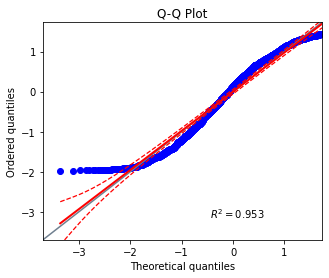

In [291]:
# вариант с qq-плотом

pg.qqplot(np.log(df_ab_test.query('testgroup == "b" and revenue > 0').revenue))

Для анализа гомогенности дисперсий воспользуемся тестом Левена:

In [292]:
levene_test = st.levene(df_ab_test.query('testgroup == "a" and revenue > 0').revenue, df_ab_test.query('testgroup == "b" and revenue > 0').revenue)
levene_test

LeveneResult(statistic=80.85567421779912, pvalue=3.779689868667878e-19)

Значение p-value оказалось меньше 0.05, поэтому мы отклоняем нулевую гипотезу о равенстве дисперсий. Следоватльно предположение о гомогенности дисперсии не выполняется.

Из анализа выше видно, что рапределения в обеих группах нельзя назвать нормальными, даже не помогает логарифмирование. Гомогенность дисперсий при этом тоже не сохраняется. Поэтому использовать t-тест мы не можем. Поэтому воспользуемся тестом Уэлча (Welch's t-test) — это статистический тест, который используется для сравнения средних значений двух независимых групп, когда предположение о равенстве дисперсий (гомогенности дисперсий) не выполняется. 

In [293]:
t_test = st.ttest_ind(df_ab_test.query('testgroup == "a" and revenue > 0').revenue, df_ab_test.query('testgroup == "b" and revenue > 0').revenue, equal_var=False)
t_test

Ttest_indResult(statistic=-1.6446302664300838, pvalue=0.10020780398916015)

Во всех случаях значение p-value оказалось больше 0.05, поэтому у нас нет основания отклонить нулевую гипотезу и слеовательно мы делаем вывод, что ARPPU в двух группах значимо не различаются.

В качестве третьей метрики выберем долю платящих пользователей в двух группах. Для этого создадим новую колонку с категориальной переменной (0 - пользователь не платил, 1 - пользователь платил). После этого создадим сопряженную таблицу - она покажет нам количество платящих и неплатящих пользователей.

In [294]:
df_ab_test["pay"] = df_ab_test["revenue"].apply(lambda x: 1 if x > 0 else 0)
df_ab_test

,user_id,revenue,testgroup,pay
0,1,0,b,0
1,2,0,a,0
2,3,0,a,0
3,4,0,b,0
4,5,0,b,0
...,...,...,...,...
404765,404766,0,a,0
404766,404767,0,b,0
404767,404768,231,a,1
404768,404769,0,a,0


In [295]:
cross_df = pd.crosstab(df_ab_test.testgroup, df_ab_test.pay)
cross_df

pay,0,1
testgroup,,
a,200175,1928
b,200862,1805


Обоснование выбора статистического критерия.

Для оценки влияния различных наборов акционных предложений на долю платящих пользователей в двух группах воспользуемся критерием хи-квадрат. 
Наши данные представляют собой категориальные переменные типа 0 и 1, поэтому мы можем воспользоваться критерием хи-квадрат. Более того наблюдения у нас независимы в двух группах.

Тогда нулевая гипотеза Но - доля платящих пользователей не будет отличаться в двух группах.
Альтернативная гипотеза H1 - доля платящих пользователей статзначимо различается.
Уровень значимсоти выберем 5 %. Для рассчета критерия хи-квадрат воспользуемся функцией chi2_contingency, которая принимает на вход таблицу сопряженности и рассчитывает p-уровень значимости.

In [296]:
chi2_contingency(cross_df)

(4.374729521260405,
 0.03647561892312613,
 1,
 array([[200239.10075104,   1863.89924896],
        [200797.89924896,   1869.10075104]]))

Значение p-уровня значимости ниже 5%, значит мы отвергаем нулевую гипотезу и делаем вывод, что распределение доли платящих пользователей в двух группах статзначимо отличаются.

Замечание: при анализе таблицы df_ab_test, а именно контрольной группы, было обнаружено 124 аномально выскоих чека (больше 35000). Такие выскоие чеки не обнаружены ни в этой группе, ни в тестовой. Остается открытым вопрос, что могло повлиять на такой сильный скачок, возможно есть смысл проанализировать отдельно данные без этих чеков, либо попробовать выяснить причину (дополнительно посмотреть на аудитории, даты и тд).

In [57]:
# аномально высокие чеки

df_ab_test.query('testgroup == "a" and revenue > 10000')

,user_id,revenue,testgroup,pay
416,417,37324,a,1
4428,4429,37304,a,1
5777,5778,37315,a,1
8065,8066,37307,a,1
8743,8744,37334,a,1
...,...,...,...,...
360696,360697,37347,a,1
378668,378669,37297,a,1
389341,389342,37298,a,1
394580,394581,37302,a,1


Выводы по 2 заданию:

В конце рассчетов выведены сведение об аномально высоких чеках в контрольной группе - есть основание предположить, что разделение групп произошло некорректно.

В ходе рассчетов было выявлено, что различные наборы акционных предложений не показали статзначимых различий у таких метрик, как ARPU и ARPPU, однако доля платящих пользователей в контрольной группе выше и эта различия статзначимы.
ARPU и ARPPU стабильны: Это означает, что пользователи, которые продолжают платить, не изменили свои расходы, несмотря на снижение доли платящих пользователей.
Меньшая доля платящих пользователей указывает на то, что изменения в тестовой группе (например, новые акционные предложения) сделали покупку менее привлекательной для части аудитории.
Таким образом, если цель акционных предложений - увеличить доход, то  оба набора предложений показывают одинаковую эффективность. Однако снижение доли платящих пользователей в тестовой группе вызывает вопросы, так как это снижает охват платёжеспособной аудитории. А если цель — повышение лояльности или конверсии (CR), то набор предложений контрольной группы лучше, так как он демонстрирует большую долю платящих пользователей.


In [ ]:
# ______________________________________________________________________________________#

Задание 3

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Для оценки результатов тематического события можно взять следующие группы метрик:

1. Анализ аудитории.

 1.1 В качестве первой метрики я бы выбрала показатель:

   avg. DAU/PAU = stickness ratio — коэффициент того, насколько часто игроки, в течение проведения тематического события,       "остаются" в продукте 
 
   Дневная аудитория (DAU) — количество уникальных пользователей, которые зашли в игру в течение суток в период проведения события. В дальнейшем сравнить эти значения с DAU обычных дней.
 
   Аудитория на период проведения события (promotion audience) (аналог(MAU))  — количество уникальных пользователей, которые зашли в приложение в период проведения события (назовем это PAU). По отношению средней дневной аудитории к аудитории за событие можно понимать частоту использования продукта в период проведения акции.
   
      
 2. Анализ активности игроков.
 
 2.1 Конверсия из пользователя в игрока, который прошел все уровни.
 
 Можно просчитать следующую воронку:  
  Все пользователи -> Доля пользователей, которые приняли участие в тематическом событии -> доля активных пользователей, которые хотя бы раз пытались пройти уровни -> доля игроков, которые прошли все уровни.
  
  Такая воронка показывает, как игроки проходят через определенную последовательность действий в продукте, на каких шагах и какая часть из них отваливается. Эти конверсии можно сравнивать каждый месяц с показателями других тематических событий, а также смотреть, на сколько эти события были привлекательы для пользователей.
 
 2.1 Среднее время прохождения уровней - показывает, сколько времени в среднем игроки тратят на прохождение всех уровней. Эта метрика важна для понимания того, насколько игра увлекательна и удерживает внимание игроков.
 
  Среднее время прохождения уровней = (Общее время игроков, зевершивших все уровни) / (количество игроков, прошедших все уровни)
  
 2.2 Количество сессий на пользователя - показывает, сколько раз в день игроки заходят в игру, также может указывать на успешность внутриигровых событий или акций. Например, если во время проведения специального события количество сессий на пользователя увеличивается, это может свидетельствовать о том, что событие было успешным и привлекло внимание игроков. 
 
 Количество сессий на пользователя = (общее количество сессий)/(количество пользователей) 
 
 2.3 Среднее количество полученных уникальных предметов на пользователя, сумма монет, среднее количество бонусов - эти метрики покажут, на сколько эффективно прошло событие. Можно сравнивать каждый месяц.
 
 
 3. Анализ доходов.
 
 Если в  игре возможны покупки, то можно проанализировать следующие метрики:
 
 3.1 Общий доход от пользователей во время проведения события.
 
 3.2 ARPU - средний доход от пользователя во время проведения события.
 
 ARPU = (общий доход) / (количество игроков)
 
 3.3 Доля платящих пользователей - посмотреть на долю пльзователей, которые совершили хотя бы одну покупку. Этот показатель можно сравнивать с обычными днями (без проведения событий) и посмотреть, способствует ли событие большим покупкам со стороны игроков.
 
 Доля платящих пользователей = (кол-во пользователей, сделавших хотя бы 1 покупку) / (количество игроков)
 
 
 4. Возвращаемость игроков
 
 Процент возвращаемости игроков - сколько игроков возвращались к игре в дни проведения события. Сравнение удержания игроков во время события с обычными днями поможет определить, было ли событие привлекательным.
 

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Кардинально менять набор метрик не стала бы. Но так как условия участия в событии стали сложнее, то предвидится отток игроков, поэтому добавила бы метрику Churn Rate (коэффициент оттока) — это метрика, которая измеряет процент игроков, которые прекращают использовать игру за период проведения события. А также изменила бы воронку:

Изменение в воронке "Конверсия из пользователя в игрока, который прошел все уровни". Необходимо добавить в эту воронку успешное прохождение каждого уровня, чтобы отследить, какой процент пользователей на каком этапе отваливается:

Все пользователи -> Доля пользователей, которые приняли участие в тематическом событии -> доля активных пользователей, которые хотя бы раз пытались пройти уровни -> доля игроков, прошедших 1-ый уровень -> доля игроков, прошедших 2-ый уровень -> доля игроков, прошедших n-ый уровень-> доля игроков, которые прошли все уровни.

А вот уже для анализа причин оттока игроков можно добавить следующие метрики:

2. Среднее количество завершенных уровней на пользователя - эта метрика покажет, сколько в среднем уровней проходит один пользователь за период проведения события. 

 Среднее количество завершенных уровней на пользователя = (общее количество завершенных уровней) / ( количество игроков)

3. Среднее количество попыток на один уровень - сколько раз в среднем каждый игрок пытлася пройти хотя бы 1 урвоень. Эта метрика покажет, насколько сложными стали уровни.

Среднее количество попыток на один уровень = (общее количество попыток) / (количество пользователей, завершивших уровень)
